# Diabetic Retinopathy Detection Using SVM and Random Forest

## Importing libraries

In [240]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pywt
from numpy import exp
from math import sqrt, pi
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import SMOTE

## Data loading and helper functions

In [243]:
def list_images_from_txt(txt_path):
    # Reads the image names from a text file (like "image001")
    with open(txt_path, 'r') as f:
        return [line.strip() for line in f.readlines()]

def load_all_images(folder, dr_cutoff=110):
    # Loads images from a folder and gives them labels (1 if DR, 0 if healthy)
    X, y, names = [], [], []
    for i in range(1, 131):
        img_name = f"image{i:03}"
        path = os.path.join(folder, img_name + ".png")
        if not os.path.exists(path): continue
        img = cv2.imread(path)  # load as COLOR
        if img is None: continue
        img = cv2.resize(img, (200, 200))
        # Save both color (for display) and grayscale (for analysis)
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        img_gray = cv2.equalizeHist(img_gray)
        X.append((img, img_gray.flatten()))  # Save color and gray
        y.append(1 if i <= dr_cutoff else 0)
        names.append(img_name)
    return X, np.array(y), names

def show_debug(img, title=""):
    # Show an image with stats for debugging
    img = np.array(img)
    print(f"{title} - min: {img.min()}, max: {img.max()}, mean: {img.mean()}")
    minv, maxv = np.min(img), np.max(img)
    if maxv > minv:
        img = (img - minv) / (maxv - minv)
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

## Loading data and splitting into Train and Test sets

In [246]:
images_folder = 'datasets/diaretdb0_fundus_images'
train_file = 'datasets/traindatasets/traindata1.txt'
test_file  = 'datasets/testdatasets/testdata1.txt'
train_names = list_images_from_txt(train_file)
test_names = list_images_from_txt(test_file)

# Load both color and gray images for each sample
all_X, all_y, all_names = load_all_images(images_folder)
train_idx = [i for i, n in enumerate(all_names) if n in train_names]
test_idx  = [i for i, n in enumerate(all_names) if n in test_names]
# Get color images just for display, gray for processing
X_train_color = [all_X[i][0] for i in train_idx]
X_train = np.array([all_X[i][1] for i in train_idx])
X_test_color = [all_X[i][0] for i in test_idx]
X_test = np.array([all_X[i][1] for i in test_idx])
y_train = all_y[train_idx]
y_test  = all_y[test_idx]

print("Train size:", len(X_train), "Test size:", len(X_test))

Train size: 10 Test size: 120


## Displaying original image

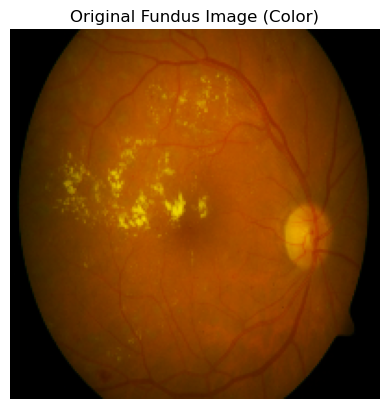

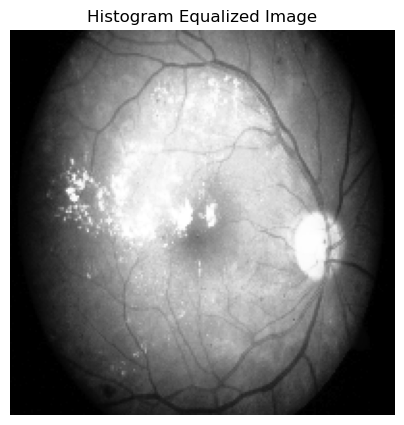

In [250]:
plt.imshow(cv2.cvtColor(X_train_color[0], cv2.COLOR_BGR2RGB))
plt.title("Original Fundus Image (Color)")
plt.axis('off')
plt.show()
sample_idx = 0
gray_img = X_train[sample_idx].reshape(200, 200) 
plt.figure(figsize=(5,5))
plt.imshow(gray_img, cmap='gray')
plt.title("Histogram Equalized Image")
plt.axis('off')
plt.show()


## Visualizing sample DR and healthy images 

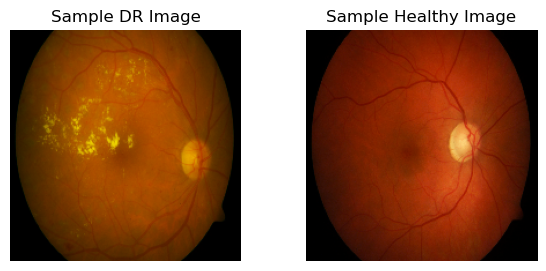

In [213]:
# Showing what a DR (disease) image and a healthy image looks like
fig, ax = plt.subplots(1, 2, figsize=(7, 3))
ax[0].imshow(cv2.cvtColor(X_train_color[y_train.tolist().index(1)], cv2.COLOR_BGR2RGB))
ax[0].set_title("Sample DR Image")
ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(X_train_color[y_train.tolist().index(0)], cv2.COLOR_BGR2RGB))
ax[1].set_title("Sample Healthy Image")
ax[1].axis('off')
plt.show()

## Matched filter, Gabor filter and K-means setup

In [218]:
def _filter_kernel_mf_fdog(L, sigma, t=3, mf=True):
    # Makes a matched filter kernel (for vessels)
    dim_y = int(L)
    dim_x = 2 * int(t * sigma)
    kernel = np.zeros((dim_y, dim_x), dtype='float32')
    center_x = dim_x / 2
    for y in range(dim_y):
        for x in range(dim_x):
            kernel[y, x] = x - center_x
    norm = 1.0 / (sqrt(2 * pi) * sigma)
    if not mf:
        norm = norm / (sigma ** 2)
    def gaussian(x):
        return norm * exp(-x**2 / (2 * sigma**2))
    def gaussian_derivative(x):
        return -x * norm * exp(-x**2 / (2 * sigma**2))
    func = gaussian if mf else gaussian_derivative
    kernel = func(kernel)
    kernel -= kernel.mean()
    return cv2.flip(kernel, -1)

def createMatchedFilterBank(base_kernel, num_angles=12):
    # Makes a bunch of matched filters rotated at different angles
    filters = [base_kernel]
    center = (base_kernel.shape[1] / 2, base_kernel.shape[0] / 2)
    for i in range(1, num_angles):
        angle = 180 * i / num_angles
        rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1)
        rotated = cv2.warpAffine(base_kernel, rotation_matrix, (base_kernel.shape[1], base_kernel.shape[0]))
        filters.append(rotated)
    return filters

def applyFilters(image, kernels):
    # Runs each filter over the image and keeps the strongest response
    filtered_images = np.array([cv2.filter2D(image, -1, k) for k in kernels])
    return np.max(filtered_images, axis=0)

def createGaborFilterBank():
    # Makes a bunch of Gabor filters (good for texture/vessel detail)
    filters = []
    ksize = 31
    for theta in np.arange(0, np.pi, np.pi / 16):
        kernel = cv2.getGaborKernel((ksize, ksize), 6, theta, 12, 0.37, 0, ktype=cv2.CV_32F)
        kernel /= 1.5 * kernel.sum()
        filters.append(kernel)
    return filters

## Preprocessing, Filtering and Clustering on one image

DWT+IDWT Output - min: -8.881784197001252e-16, max: 255.00000000000009, mean: 109.2906


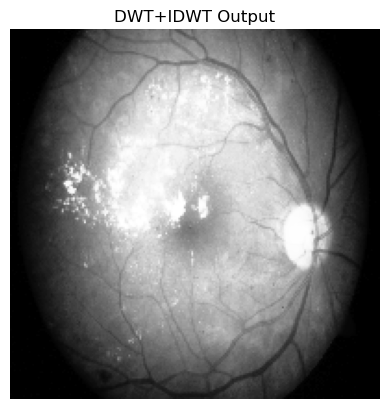

Matched Filter Output (Normalized) - min: -9.520473457870107, max: 1456.2013290952818, mean: 609.5965856419189


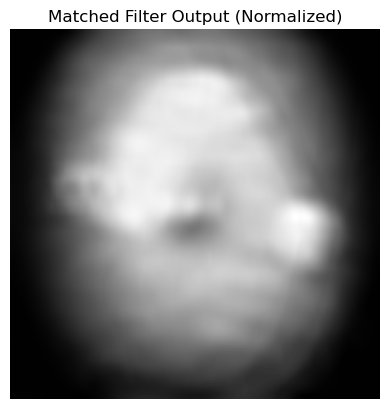

Gabor Filter Output (Normalized) - min: 9.377900924947527e-13, max: 5169.9629075827725, mean: 584.4122022485855


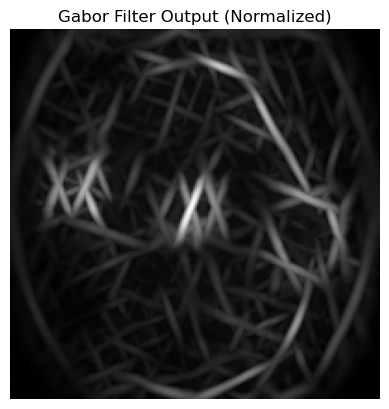

Unique values in K-means image: [ 20 114 208]


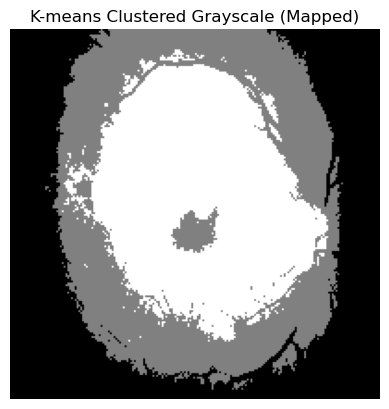

In [221]:
idx = 0  # just use first image
img_demo = X_train[idx].reshape((200, 200))

# DWT (Wavelet transform) - just to simulate preprocessing
coeffs = pywt.dwt2(img_demo, 'haar')
img_wavelet = pywt.idwt2(coeffs, 'haar')
show_debug(img_wavelet, "DWT+IDWT Output")

# Matched filter (makes vessels pop out)
base_mf = _filter_kernel_mf_fdog(20, 5)
mf_bank = createMatchedFilterBank(base_mf, 4)
mf_filtered = applyFilters(img_wavelet, mf_bank)
show_debug(mf_filtered, "Matched Filter Output (Normalized)")

# Gabor filter (shows oriented lines/textures)
gabor_bank = createGaborFilterBank()
gabor_filtered = applyFilters(img_wavelet, gabor_bank)
show_debug(gabor_filtered, "Gabor Filter Output (Normalized)")

# K-means clustering (segments into 3 big regions)
Z = img_wavelet.reshape((-1, 1)).astype(np.float32)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
K = 3
_, label, center = cv2.kmeans(Z, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
center = np.uint8(center)
res = center[label.flatten()]
res2 = res.reshape(img_wavelet.shape)
print("Unique values in K-means image:", np.unique(res2))
# Map clusters to 0,1,2 for clean display
unique_vals = np.unique(res2)
img_kmeans_mapped = np.zeros_like(res2)
for i, val in enumerate(sorted(unique_vals)):
    img_kmeans_mapped[res2 == val] = i
plt.imshow(img_kmeans_mapped, cmap='gray', vmin=0, vmax=2)
plt.title("K-means Clustered Grayscale (Mapped)")
plt.axis('off')
plt.show()

## Processing all images - DWT, K-means clustering

In [224]:
def dwt_all(X):
    # Applies DWT to all images
    return [pywt.idwt2(pywt.dwt2(x.reshape(200,200), 'haar'), 'haar').flatten() for x in X]

X_train_dwt = np.array(dwt_all(X_train))
X_test_dwt = np.array(dwt_all(X_test))

def kmeans_all(X_dwt):
    # Clusters each image into 3 groups
    X_km = []
    for x in X_dwt:
        img = x.reshape((200,200))
        Z = img.reshape((-1,1)).astype(np.float32)
        _, label, center = cv2.kmeans(Z, 3, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
        center = np.uint8(center)
        clustered = center[label.flatten()].reshape(img.shape)
        uniq = np.unique(clustered)
        mapped = np.zeros_like(clustered)
        for i, val in enumerate(sorted(uniq)):
            mapped[clustered == val] = i
        X_km.append(mapped.flatten())
    return np.array(X_km)

X_train_km = kmeans_all(X_train_dwt)
X_test_km  = kmeans_all(X_test_dwt)

## Shrink features using PCA (just keeps best 10 features for speed)

In [252]:
X_train_flat = X_train_km.reshape(len(X_train_km), -1)
X_test_flat  = X_test_km.reshape(len(X_test_km), -1)
n_pca = min(10, len(X_train_flat))
pca = PCA(n_components=n_pca, random_state=42)
X_train_pca = pca.fit_transform(X_train_flat)
X_test_pca  = pca.transform(X_test_flat)
print("PCA shapes:", X_train_pca.shape, X_test_pca.shape)

PCA shapes: (10, 10) (120, 10)


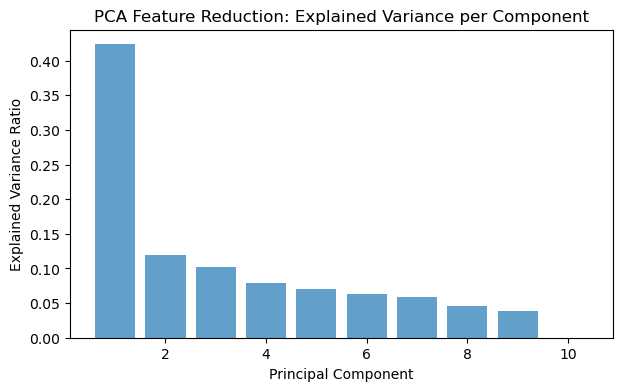

In [256]:
# Plot the explained variance ratio for each principal component
plt.figure(figsize=(7, 4))
plt.bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, alpha=0.7)
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Component')
plt.title('PCA Feature Reduction: Explained Variance per Component')
plt.show()

## SMOTE Balancing

In [228]:
if len(np.unique(y_train)) == 2 and np.min(np.bincount(y_train.astype(int))) > 1:
    sm = SMOTE(random_state=42, k_neighbors=1)
    X_train_bal, y_train_bal = sm.fit_resample(X_train_pca, y_train)
else:
    X_train_bal, y_train_bal = X_train_pca, y_train
print("Class counts after SMOTE (if applied):", np.bincount(y_train_bal.astype(int)))

Class counts after SMOTE (if applied): [8 8]


## Training a Support Vector Machine and a Random Forest

In [233]:
svm = SVC(kernel='rbf', C=10, gamma=0.01, class_weight='balanced')
svm.fit(X_train_bal, y_train_bal)
svm_preds = svm.predict(X_test_pca)

rf = RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced')
rf.fit(X_train_bal, y_train_bal)
rf_preds = rf.predict(X_test_pca)

print("SVM Results")
print(classification_report(y_test, svm_preds, zero_division=0))
print("Random Forest Results")
print(classification_report(y_test, rf_preds, zero_division=0))

SVM Results
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        18
           1       0.85      1.00      0.92       102

    accuracy                           0.85       120
   macro avg       0.42      0.50      0.46       120
weighted avg       0.72      0.85      0.78       120

Random Forest Results
              precision    recall  f1-score   support

           0       0.05      0.06      0.05        18
           1       0.83      0.79      0.81       102

    accuracy                           0.68       120
   macro avg       0.44      0.42      0.43       120
weighted avg       0.71      0.68      0.70       120



## Showing a bar chart to compare the two models

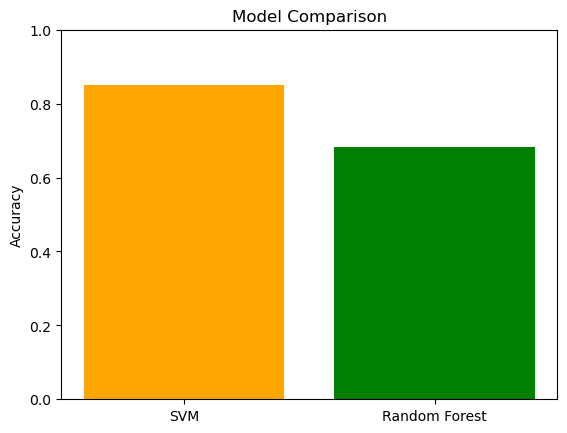

In [236]:
plt.bar(['SVM', 'Random Forest'],
        [accuracy_score(y_test, svm_preds), accuracy_score(y_test, rf_preds)],
        color=['orange', 'green'])
plt.ylim(0,1)
plt.ylabel('Accuracy')
plt.title('Model Comparison')
plt.show()